<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>Code</h1>

In [1]:
# lets try to write the code 
# our training corpus will be moby dick
# https://www.gutenberg.org/ebooks/2701
# download the palin-text and remove the head and tail
# our test corpus is a paragraph from The Adventures of sherlock holmes
# https://www.gutenberg.org/ebooks/1661
# again you can choose any text

In [2]:
import numpy as np
from nltk.tokenize import RegexpTokenizer
import string
from random import shuffle
import matplotlib.pyplot as plt

In [34]:
# a message from Adventures of sherlock holmes
alphabet = string.ascii_lowercase
message = '''My cabby drove fast. I don't think I ever drove faster, but the others
were there before us. The cab and the landau with their steaming horses
were in front of the door when I arrived. I paid the man and hurried
into the church. There was not a soul there save the two whom I had
followed and a surpliced clergyman, who seemed to be expostulating with
them. They were all three standing in a knot in front of the altar. I
lounged up the side aisle like any other idler who has dropped into a
church. Suddenly, to my surprise, the three at the altar faced round to
me, and Godfrey Norton came running as hard as he could towards me.'''

In [35]:
# for we keep only lower case leters in the message
def process(text):
    text = text.replace('\n',' ')
    return "".join([t.lower() for t in text if t.lower() in alphabet + " "])

In [36]:
message = process(message)
message

'my cabby drove fast i dont think i ever drove faster but the others were there before us the cab and the landau with their steaming horses were in front of the door when i arrived i paid the man and hurried into the church there was not a soul there save the two whom i had followed and a surpliced clergyman who seemed to be expostulating with them they were all three standing in a knot in front of the altar i lounged up the side aisle like any other idler who has dropped into a church suddenly to my surprise the three at the altar faced round to me and godfrey norton came running as hard as he could towards me'

In [37]:
# next lets load in our train
f =  open('datasets/moby_dick.txt',encoding='utf-8')
corpus = f.read().lower()

In [38]:
# next lets build up our unigram and bigram probabilities
V = len(alphabet) # size of vocabulary
unigram = np.ones(V) # count of each character + add one smoothing
bigram = np.ones((V,V)) # bigram probabilities + add one smoothing

In [39]:
# build unigram
for ch in corpus:
    if ch in alphabet:
        unigram[ord(ch)-ord('a')] +=1
unigram = unigram/(unigram.sum()) # obtain probabilities
unigram = np.log(unigram) # obtain log probabilities

In [40]:
# build bigram
bigram = np.ones((V,V)) # bigram probabilities + add one smoothing
for i in range(len(corpus)-1):
    ch1 = corpus[i]
    ch2 = corpus[i+1]
    if ch1 in alphabet and ch2 in alphabet:
        bigram[ord(ch1)-ord('a'),ord(ch2)-ord('a')] +=1
bigram = (bigram.T/bigram.sum(axis=1)).T # obtain probabilities
bigram = np.log(bigram) # obtain log probabilities

In [41]:
# now we need a function to get the log-likelihood of a sentence
# this will later take a decoded message using the DNA string and return the the log-likelihood
# so this is our fitness function
def fit_word(word):
    logP = unigram[ord(word[0])-ord('a')]
    for i in range(1,len(word)-1):
        ch1 = word[i]
        ch2 = word[i+1]
        logP += bigram[ord(ch1)-ord('a'),ord(ch2)-ord('a')]
    return logP

def fit_sentence(sentence):
    logP = 0
    sentence = sentence.split(' ')
    for word in sentence:
        logP += fit_word(word)
    return logP

In [42]:
# next we want to define encode and decode functions

def encode(message,map_):
    encoded = ""
    for ch in message:
        if ch == ' ':
            encoded += ' '
        else:
            encoded += map_[ch]
            
    return encoded

def decode(message,map_):
    rev_map_ = {v:k for k,v in map_.items()}
    decoded = ""
    for ch in message:
        if ch == ' ':
            decoded += ' '
        else:
            decoded += rev_map_[ch]
            
    return decoded

# another function to change a DNA list to dict
def DNA_to_dict(DNA):
    alphabet = string.ascii_lowercase
    dict_ = {}
    for ch1,ch2 in zip(alphabet,DNA):
        dict_[ch1] = ch2
    return dict_

# another function to get a random DNA list , lists will be easier tow work with than strings
def get_random_DNA():
    alphabet = string.ascii_lowercase
    DNA = list(alphabet)
    shuffle(DNA)
    return DNA

In [43]:
true_encoding = get_random_DNA()
true_dict = DNA_to_dict(true_encoding)

In [44]:
encoded = encode(message,true_dict)

In [45]:
# we want a function to get children form parent DNA
def get_children(DNA,max_children):
    children = []
    for _ in range(max_children):
        child = DNA.copy()
        i1 = np.random.randint(0,len(child))
        i2 = np.random.randint(0,len(child))
        child[i1],child[i2] = child[i2],child[i1]
        children.append(child)
    return children

In [46]:
# now lets begin by filling our pool with some parent
pool = []
max_parents = 20 # at each iteration we will get only fittest 5 parents
max_children = 5 # each aprent will have 5 children
for _ in range(max_parents):
    pool.append(get_random_DNA())

epochs = 1000
# next lets loop
costs = []
for _ in range(epochs):
    # first lets add all the children to the pool
    children = []
    for parent in pool:
        children += get_children(parent,max_children)
    pool += children
    
    # next for every DNA we get the likelihood
    fitness = []
    for DNA in pool:
        decode_dict = DNA_to_dict(DNA)
        decoded = decode(encoded,decode_dict)
        score = fit_sentence(decoded)
        fitness.append(score)
    
    # next we take the fittest of the population
    idx = np.argpartition(np.array(fitness)*-1, max_parents)[:max_parents]
    pool = [pool[i] for i in idx]
    # append best score to costs
    costs.append(fitness[idx[0]])

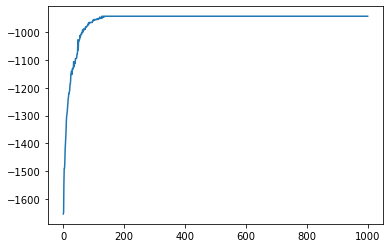

In [47]:
plt.plot(costs)
plt.show()

In [48]:
best_DNA = pool[0]
best_dict = DNA_to_dict(best_DNA)

In [56]:
print("Original message: ",message)
print('-------------------------------------------------------------------------------------')
print("Decoded  message: ",decode(encoded,best_dict))

Original message:  my cabby drove fast i dont think i ever drove faster but the others were there before us the cab and the landau with their steaming horses were in front of the door when i arrived i paid the man and hurried into the church there was not a soul there save the two whom i had followed and a surpliced clergyman who seemed to be expostulating with them they were all three standing in a knot in front of the altar i lounged up the side aisle like any other idler who has dropped into a church suddenly to my surprise the three at the altar faced round to me and godfrey norton came running as hard as he could towards me
-------------------------------------------------------------------------------------
Decoded  message:  my cabby drove fast i dont think i ever drove faster but the others were there before us the cab and the landau with their steaming horses were in front of the door when i arrived i paid the man and hurried into the church there was not a soul there save the

In [50]:
# lets get wrong letters
for (k,true_v),(_,best_v) in zip(true_dict.items(),best_dict.items()):
    if true_v != best_v:
        print(k," ---> ",true_v , 'but we predicted: ',k,' --->',best_v)

j  --->  q but we predicted:  j  ---> c
z  --->  c but we predicted:  z  ---> q


In [51]:
original_cost = fit_sentence(message)
best_cost = fitness[idx[0]]
print('Original message likelihood' , original_cost,"Best message likelihood ",best_cost)

Original message likelihood -942.66541918156 Best message likelihood  -942.66541918156


In [52]:
# the original message contained neither z nor j , this means we actually got a perfect decoding :)
# in some cases we might find that Best message likelihood is better than Original message likelihood
# this means that within the context of moby dick the best message is more likely to occur